In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [49]:
# Load the dataset
train_data = pd.read_csv('./Data/train (1).csv', index_col='id')
test_data = pd.read_csv('./Data/test (1).csv')


In [50]:
train_data.head(10)
#test_data.head(10)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0


In [52]:
# Building Covariance Matrix across variables
cov_matrix = train_data.drop(columns=['Driver',"Race","Year","Compound"]).cov()
print(cov_matrix)

                         PitStop   LapNumber      Stint    TyreLife  \
PitStop                 0.117590    0.647998   0.046878   -0.452657   
LapNumber               0.647998  287.582632  11.672553  107.774323   
Stint                   0.046878   11.672553   0.902869    1.468999   
TyreLife               -0.452657  107.774323   1.468999   96.066226   
Position                0.169317    0.174613   0.758396   -6.247157   
LapTime (s)            -0.002962  -43.082673  -1.293910  -25.834202   
LapTime_Delta          -0.127460   23.307290   0.717930   15.483466   
Cumulative_Degradation -1.653640 -160.798355  -6.149469  -59.981488   
RaceProgress            0.005140    4.142836   0.170875    1.545729   
Position_Change        -0.147920    0.703079  -0.054157    2.054276   
PitNextLap              0.006649    1.808064   0.075185    1.070256   

                         Position  LapTime (s)  LapTime_Delta  \
PitStop                  0.169317    -0.002962      -0.127460   
LapNumber        

In [54]:
# Building Correlation Matrix across variables
corr_matrix = train_data.drop(columns=['Driver',"Race","Year","Compound"]).corr()

# Printing pairs that are greater than threshold of 0.5 (Magnitude of correlation)
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"{corr_matrix.columns[i]} and {corr_matrix.columns[j]} have a correlation of {corr_matrix.iloc[i, j]:.2f}")

print(corr_matrix)

Stint and LapNumber have a correlation of 0.72
TyreLife and LapNumber have a correlation of 0.65
RaceProgress and LapNumber have a correlation of 0.96
RaceProgress and Stint have a correlation of 0.71
RaceProgress and TyreLife have a correlation of 0.62
                         PitStop  LapNumber     Stint  TyreLife  Position  \
PitStop                 1.000000   0.111431  0.143869 -0.134678  0.093536   
LapNumber               0.111431   1.000000  0.724390  0.648408  0.001951   
Stint                   0.143869   0.724390  1.000000  0.157733  0.151200   
TyreLife               -0.134678   0.648408  0.157733  1.000000 -0.120744   
Position                0.093536   0.001951  0.151200 -0.120744  1.000000   
LapTime (s)            -0.000437  -0.128485 -0.068869 -0.133304  0.017899   
LapTime_Delta          -0.008458   0.031275  0.017193  0.035947 -0.012633   
Cumulative_Degradation -0.088052  -0.173135 -0.118171 -0.111742 -0.026649   
RaceProgress            0.059177   0.964539  0.710020

In [ ]:
# Dropping useless columns
cols_to_drop = ['Driver', 'Race','Year']
train_data.drop(columns=cols_to_drop, inplace=True)
test_data.drop(columns=cols_to_drop[:-1], inplace=True)  # test data doesn't have 'milliseconds'

# Changing column "Compound" to categorical
train_data['Compound'] = train_data['Compound'].astype('category')
test_data['Compound'] = test_data['Compound'].astype('category')

# Check for missing values
print(train_data.isnull().sum())
print(test_data.isnull().sum())


Compound                  0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64
id                        0
Compound                  0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64


# Features
Model needs to be able to handle discrete / categorical variables. Some form of unsupervised learning model

1) 

Mean Squared Error: 0.10229084118959786
R^2 Score: 0.12560375588759054
AUC Score: 0.6882217533234054


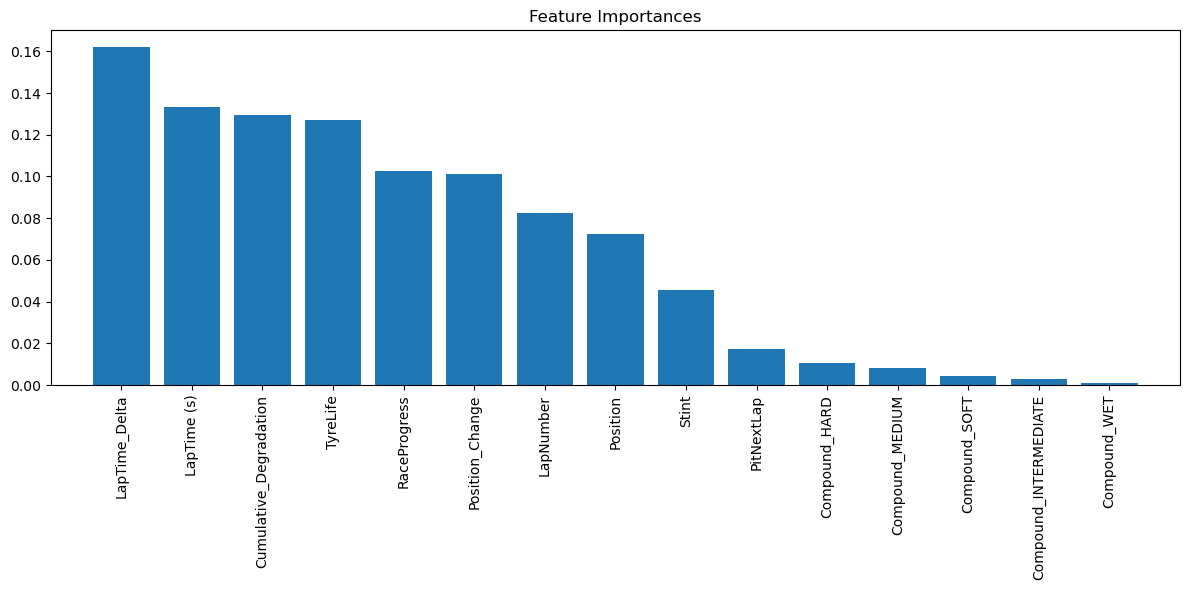

In [ ]:
# Random Forest Classifier

# Encoding the categorical variable 'Compound' and "PitStop" using one-hot encoding
train_data_encoded = pd.get_dummies(train_data, columns=['Compound', 'PitStop'])
test_data_encoded = pd.get_dummies(test_data, columns=['Compound'])

# Random Split on train_data to create a validation set
X = train_data_encoded.drop(columns=[col for col in train_data_encoded.columns if col.startswith('PitStop_')])
y = train_data_encoded[[col for col in train_data_encoded.columns if col.startswith('PitStop_')]]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42) 

# Train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predict on the validation set
y_pred = rf_classifier.predict(X_val)

# Evaluate the model
# Using Area under ROC curve (AUC) for evaluation
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(f'AUC Score: {auc}')

# Plotting out feature importances
feature_importances = rf_classifier.feature_importances_
features = X_train.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), features[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()



# From EDA

Most important features are 
1) LapTime_Delta
2) LapTime
3) Cumulative_Degradation
4) TyreLife
5) RaceProgress
6) Position_Change